Importing Needed Libraries - Routing to Proper Device

In [20]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader, random_split, Dataset
from PIL import Image

print("torch:", torch.__version__)
device = "cuda"  # Change device in the runtime settings - to GPU T4
print("device:", device)

def set_seed(seed: int):                                                                       # Here for reproducability
    """Make results as reproducible as possible across runs."""
    import os, random
    import numpy as np
    import torch

    # os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Deterministic flags (safe on CPU; on GPU some ops may error if non-deterministic)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception as e:
        print("Warning: could not enable full deterministic algorithms:", e)

seed=42
set_seed(seed)                                                                                        # Here for reproducability

torch: 2.11.0+cu128
device: cuda


Importing From Kaggle API - Get Kaggle key first - Already Downloaded

In [21]:
!export KAGGLE_API_TOKEN=KGAT_6e0db17c19cd9ec6f55621b971c1014d
!mkdir -p ~/.kaggle && echo KGAT_6e0db17c19cd9ec6f55621b971c1014d > ~/.kaggle/access_token && chmod 666 ~/.kaggle/access_token
!kaggle competitions list

!export KAGGLE_API_TOKEN=KGAT_d77bc5e53c781f271763950cf13abd1c
!mkdir -p ~/.kaggle && echo KGAT_d77bc5e53c781f271763950cf13abd1c > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token
!kaggle competitions list

ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                               2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                       2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection             2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3          

In [22]:
# Code that kaggle said to run to get access to the competition files
import kagglehub

# Download latest version
path = kagglehub.competition_download('ucsc-cse-144-spring-2026-final-project')

print("Path to competition files:", path)

Path to competition files: /root/.cache/kagglehub/competitions/ucsc-cse-144-spring-2026-final-project


Data Pipeline - Dataset and DataLoader - IN PROGRESS

In [38]:

batch_size = 32  # For now, can change to 32 for small amount of input data
num_workers = 0                                                                 # Here for reproducability
mean=[0.485, 0.456, 0.406]                                                      # ImageNet stats - that is what the model was trained on
std=[0.229, 0.224, 0.225]
val_p = 0.2 # portion of training data


class UnlabeledDataset(Dataset):
  def __init__(self, root, transform=None):
      self.root   = root
      self.transform = transform
      self.images    = sorted(os.listdir(root))

  def __len__(self):
      return len(self.images)

  def __getitem__(self, idx):
      img_path = os.path.join(self.root, self.images[idx])
      image    = Image.open(img_path).convert('RGB')
      if self.transform:
          image = self.transform(image)
      return image, self.images[idx]

train_path = path + '/train'
test_path = path + '/test'


#data augmentation to expand training dataset
train_tf = v2.Compose([
           v2.ToImage(),
           v2.ToDtype(torch.uint8, scale=True),
           v2.Resize((224, 224)),
           v2.RandomResizedCrop(size=(224, 224), antialias=True),                   # Augmentation
           v2.RandomHorizontalFlip(p=0.5),                                          # Augmentation
           v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),            # Augmentation
           # v2.RandomRotation(20),                                                   # Augmentation
           v2.ToDtype(torch.float32, scale=True),
           v2.Normalize(mean, std)
])

test_tf = v2.Compose([
          v2.ToImage(),
          v2.ToDtype(torch.uint8, scale=True),
          v2.Resize((224, 224)),
          v2.ToDtype(torch.float32, scale=True),
          v2.Normalize(mean, std)
])

train_set = datasets.ImageFolder(root=train_path, transform=train_tf)
val_set   = datasets.ImageFolder(root=train_path,  transform=test_tf)
test_set   = UnlabeledDataset(root=test_path,  transform=test_tf)

train_size = int((1-val_p) * len(train_set))
val_size   = len(train_set) - train_size

train_set, _ = random_split(train_set, [train_size, val_size], generator=torch.Generator().manual_seed(42))
_, val_set = random_split(val_set, [train_size, val_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(dataset=train_set,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=0,
                          drop_last=True
)
val_loader =   DataLoader(dataset=val_set,
                          batch_size=batch_size,
                          shuffle=False,
                          num_workers=0
)
test_loader =  DataLoader(dataset=test_set,
                          batch_size=batch_size,
                          shuffle=False,
                          num_workers=0
)

print("train/val/test:", len(train_set), len(val_set), len(test_set))

train/val/test: 863 216 1036


Define the Model - EfficientNet with only Classifier Unfrozen

Unfreezing 3 Layers now

In [39]:
ckpt_path = "./checkpoints/best_transfer_efficientnet.pt"
number_classes = 100
epochs = 25
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Freezing appropriate layers
for param in model.features.parameters():
  param.requires_grad = False
for param in model.features[-3:].parameters():
    param.requires_grad = True
model.classifier[1] = nn.Linear(model.classifier[1].in_features, number_classes)

# verify that not every layer is trainable
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

# Changing the dropout
for name, module in model.classifier.named_modules():
    if isinstance(module, nn.Dropout):
        module.p = 0.5
for name, module in model.features[-3:].named_modules():  # only unfrozen layers
    if isinstance(module, nn.Dropout):
        module.p = 0.3   # subtle

# Setting the optimizer
optimizer = torch.optim.AdamW([
    {'params': model.features[-5:-3].parameters(), 'lr': 1e-4},  # earlier blocks
    {'params': model.features[-3:].parameters(),   'lr': 1e-3},  # later blocks
    {'params': model.classifier.parameters(),      'lr': 1e-2},  # classifier head
])

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=epochs
)

# Making sure model and data are sent to device
model = model.to(device)

print("Trainable:", trainable, "Total:", total)
# print(model.classifier)

Trainable: 3283840 Total: 4135648


Training Function

In [40]:
criterion = nn.CrossEntropyLoss() # Moved optimizer to the model cell

def train_one_epoch(model, loader):
    """Train for one epoch and return (avg_loss, accuracy)."""
    # - Set model to training mode
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    # - Loop through batches in the loader
    for batch, (X,y) in enumerate(loader):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()           #   * Zero gradients
        prediction = model(X)           #   * Forward pass
        loss = criterion(prediction,y)  #   * Compute loss
        loss.backward()                 #   * Backward pass
        optimizer.step()                #   * Optimizer step

        total_loss += loss.item()
        predicted = prediction.argmax(dim=1)
        correct+= (predicted == y).sum().item()
        total += y.size(0)
    avg_loss = total_loss/len(loader)
    accuracy = correct/total
    # - Track total loss and accuracy (IMPORTANT: get predicted labels and compare with targets)
    # - Return average loss and accuracy
    return avg_loss, accuracy

Validation Function

In [41]:
# Q3.2: Validation function
@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model and return (avg_loss, accuracy)."""

    model.eval()                                 # - Set model to evaluation mode

    total_loss = 0.0                             # - Creating variables for loss and accuracy calculations
    correct = 0
    total = 0

    for X, y in loader:
        X, y = X.to(device), y.to(device)        # - Loop through batches without computing gradients
        prediction = model(X)
        loss = criterion(prediction,y)
        total_loss += loss.item()
        predicted = prediction.argmax(dim=1)
        correct+= (predicted == y).sum().item()
        total += y.size(0)
    avg_loss = total_loss/len(loader)            # computing loss and accuracy
    accuracy = correct/total

    return avg_loss, accuracy

Training Loop

In [43]:
def train_all_epochs(epochs, model, optimizer, criterion):
  history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
  best_val_acc = 0.0
  best_epoch = -1
  os.makedirs(os.path.dirname(ckpt_path), exist_ok=True)

  # - Loop through epochs
  for i in range(epochs):
      # - Each epoch: train, validate, log metrics
      train_loss, train_accuracy = train_one_epoch(model, train_loader)
      valid_loss, valid_accuracy = evaluate(model, val_loader)
      scheduler.step()

      history["train_loss"].append(train_loss)
      history["train_acc"].append(train_accuracy)
      history["val_loss"].append(valid_loss)
      history["val_acc"].append(valid_accuracy)

      # - Track best validation accuracy and save checkpoint when improved
      if (valid_accuracy > best_val_acc):
          best_epoch = i
          best_val_acc = valid_accuracy
          torch.save(
              {"model_state_dict": model.state_dict(), "epoch": i},
              ckpt_path
          )

      # - Print training and validation metrics each epoch
      print(i+1, "train_loss:", train_loss, "train_accuracy:", train_accuracy)
      print("  valid_loss:", valid_loss, "valid_accuracy:", valid_accuracy)

  print("Best val acc:", best_val_acc, "at epoch", best_epoch)
  print("Saved to:", ckpt_path)

  return history

history = train_all_epochs(epochs, model, optimizer, criterion)

1 train_loss: 0.8438829424289557 train_accuracy: 0.7800480769230769
  valid_loss: 2.773886101586478 valid_accuracy: 0.48148148148148145
2 train_loss: 0.8151065386258639 train_accuracy: 0.7752403846153846
  valid_loss: 2.9465550695146834 valid_accuracy: 0.4675925925925926
3 train_loss: 0.7732101678848267 train_accuracy: 0.7920673076923077
  valid_loss: 3.2218784434454784 valid_accuracy: 0.4166666666666667
4 train_loss: 0.9331577844344653 train_accuracy: 0.7776442307692307
  valid_loss: 2.8591128417423795 valid_accuracy: 0.4583333333333333
5 train_loss: 0.7093878376942414 train_accuracy: 0.796875
  valid_loss: 2.6847014086587087 valid_accuracy: 0.46296296296296297
6 train_loss: 0.6813631103588984 train_accuracy: 0.8088942307692307
  valid_loss: 2.8285180841173445 valid_accuracy: 0.4583333333333333
7 train_loss: 0.6738118993548247 train_accuracy: 0.8269230769230769
  valid_loss: 2.693371159689767 valid_accuracy: 0.5138888888888888
8 train_loss: 0.6050659612967417 train_accuracy: 0.84375
 

In [26]:
from sklearn.model_selection import StratifiedKFold

n_splits = 5

k_fold = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=42
)

# dataset should return (image, label)
labels = [train_set[i][1] for i in range(len(train_set))]

for fold, (train_idx, val_idx) in enumerate(k_fold.split(range(len(train_set)), labels)):

    print(f"Fold {fold + 1}")

    train_dataset = datasets.Subset(train_set, train_idx)
    val_dataset = datasets.Subset(val_set, val_idx)

    train_loader = DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        num_workers=4
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        num_workers=4
    )

    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    # Freezing appropriate layers
    for param in model.features.parameters():
      param.requires_grad = False
    for param in model.features[-3:].parameters():
        param.requires_grad = True
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, number_classes)
    # Changing the dropout
    for name, module in model.classifier.named_modules():
        if isinstance(module, nn.Dropout):
            module.p = 0.5
    for name, module in model.features[-3:].named_modules():  # only unfrozen layers
        if isinstance(module, nn.Dropout):
            module.p = 0.3
    optimizer = torch.optim.AdamW([
        {'params': model.features[-5:-3].parameters(), 'lr': 1e-4},  # earlier blocks
        {'params': model.features[-3:].parameters(),   'lr': 1e-3},  # later blocks
        {'params': model.classifier.parameters(),      'lr': 1e-2},  # classifier head
    ])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )
    model = model.to(device)

    train_all_epochs(epochs, model, optimizer, criterion, scheduler)

    print(f"Validation Accuracy: {acc:.4f}")

NameError: name 'full_train_data' is not defined

Curves

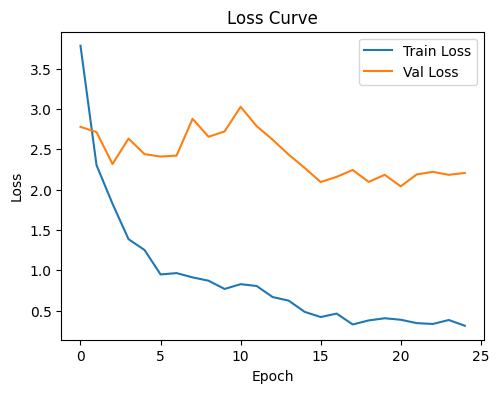

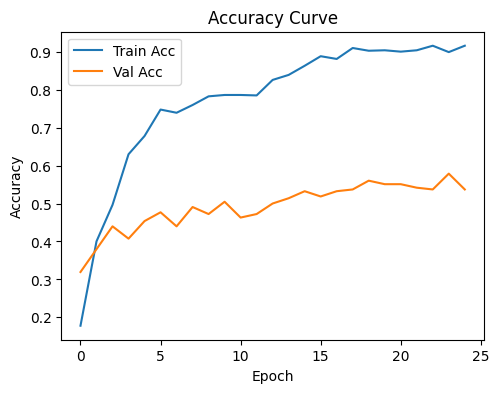

In [9]:
# Q3.4: Plot curves
# ========== YOUR CODE STARTS HERE ==========
# TODO:
# - Create two plots: one for loss (train vs val), one for accuracy (train vs val)
# - Use the history dictionary to get the values
# - Add labels, legends, and display the plots

# Loss ------------------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'],   label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Accuracy --------------------------------------------------------------------

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'],   label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# ========== YOUR CODE ENDS HERE ============

Testing